In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix, 
                             classification_report, mean_squared_error, r2_score)
import warnings
warnings.filterwarnings('ignore')

print("Bibliothèques importées")

Bibliothèques importées


In [2]:
df = pd.read_csv('../data/processed/dataset_clean.csv')
print(f"Shape : {df.shape}")
print(f"Colonnes : {df.columns.tolist()}")
df.head()

Shape : (7527, 11)
Colonnes : ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Prix_Revente', 'Categorie', 'Source', 'Rapport_Collecte', 'Source_encoded', 'Categorie_encoded']


,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte,Source_encoded,Categorie_encoded
0,-0.793268,-0.579573,-0.524702,-0.020004,-1.625915,0.835439,Papier,Collecte_Citoyenne,Lot de papier récupéré dans un site non rensei...,1,1.0
1,-0.391841,-0.625295,-0.524702,-0.103729,-0.979196,4.727748,Plastique,Usine_A,"Lot plastique à l'Usine A. Volume 64.7 L, poid...",2,2.0
2,-0.579926,-0.777312,-0.524702,-0.143717,-0.655836,3.295478,Plastique,Usine_B,Déchet plastique collecté à l'Usine B. Poids 3...,3,2.0
3,1.452968,1.833516,-0.524702,-0.208598,0.637604,5.632800,Verre,Collecte_Citoyenne,Déchets en verre identifiés lors d'une collect...,1,3.0
4,0.722926,0.750043,-0.524702,-0.208870,0.960963,3.965015,Verre,Collecte_Citoyenne,Déchets en verre identifiés via la collecte ci...,1,3.0


In [3]:
# Garder seulement les lignes avec Categorie connue
df_ml = df[df['Categorie'].notna()].copy()
print(f"Lignes avec labels : {len(df_ml)}")

# Features et cible
features = ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Source_encoded']
X = df_ml[features]
y = df_ml['Categorie']

print(f"X shape : {X.shape}")
print(f"Distribution cible :\n{y.value_counts()}")

Lignes avec labels : 7123
X shape : (7123, 6)
Distribution cible :
Categorie
Plastique    1920
Verre        1919
Métal        1705
Papier       1579
Name: count, dtype: int64


In [4]:
# Split train / temp (70 / 30)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Split temp → val / test (50 / 50)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train : {X_train.shape[0]} lignes ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Val   : {X_val.shape[0]} lignes ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test  : {X_test.shape[0]} lignes ({X_test.shape[0]/len(X)*100:.1f}%)")

Train : 4986 lignes (70.0%)
Val   : 1068 lignes (15.0%)
Test  : 1069 lignes (15.0%)


In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

modeles = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

resultats = {}
for nom, modele in modeles.items():
    modele.fit(X_train, y_train)
    y_pred = modele.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    resultats[nom] = {'Accuracy': acc, 'F1-Score': f1}
    print(f"{nom:25s} → Accuracy: {acc:.4f} | F1: {f1:.4f}")

Logistic Regression       → Accuracy: 0.9672 | F1: 0.9672
Random Forest             → Accuracy: 1.0000 | F1: 1.0000
Gradient Boosting         → Accuracy: 1.0000 | F1: 1.0000
SVM                       → Accuracy: 0.9878 | F1: 0.9878
KNN                       → Accuracy: 0.9972 | F1: 0.9972
Decision Tree             → Accuracy: 1.0000 | F1: 1.0000


                     Accuracy  F1-Score
Random Forest          1.0000    1.0000
Gradient Boosting      1.0000    1.0000
Decision Tree          1.0000    1.0000
KNN                    0.9972    0.9972
SVM                    0.9878    0.9878
Logistic Regression    0.9672    0.9672


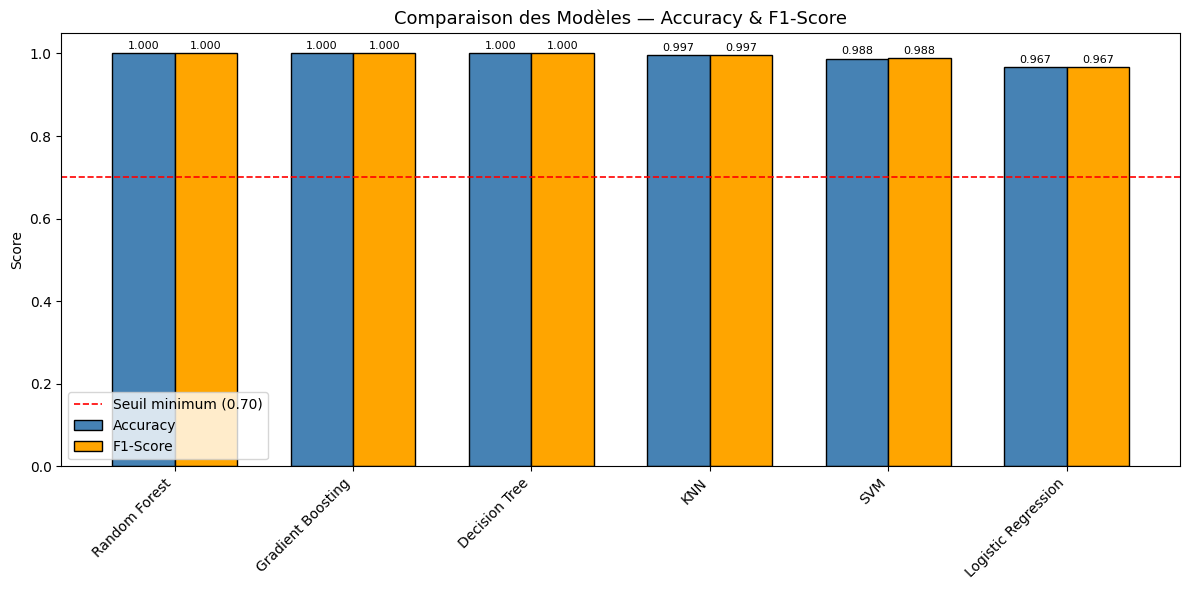

In [7]:
df_resultats = pd.DataFrame(resultats).T.sort_values('Accuracy', ascending=False)
print(df_resultats.round(4))

# Comparaison avec Accuracy ET F1-Score
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(df_resultats))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], df_resultats['Accuracy'], width,
               label='Accuracy', color='steelblue', edgecolor='black')
bars2 = ax.bar([i + width/2 for i in x], df_resultats['F1-Score'], width,
               label='F1-Score', color='orange', edgecolor='black')

# Seuil minimum
ax.axhline(y=0.70, color='red', linestyle='--', linewidth=1.2, label='Seuil minimum (0.70)')

# Valeurs au dessus des barres
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_title('Comparaison des Modèles — Accuracy & F1-Score', fontsize=13)
ax.set_ylabel('Score')
ax.set_xticks(list(x))
ax.set_xticklabels(df_resultats.index, rotation=45, ha='right')
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
# GridSearchCV sur Random Forest (meilleur candidat)
param_grid = {
    'n_estimators':      [100, 200],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f"\nMeilleurs paramètres : {grid_search.best_params_}")
print(f"   Accuracy CV (validation croisée) : {grid_search.best_score_:.4f}")

# Mettre à jour le modèle Random Forest avec la version tunée
modeles['Random Forest'] = grid_search.best_estimator_

# Recalculer son score sur le val set
acc_tuned = accuracy_score(y_val, grid_search.best_estimator_.predict(X_val))
f1_tuned  = f1_score(y_val, grid_search.best_estimator_.predict(X_val), average='weighted')
resultats['Random Forest (tuné)'] = {'Accuracy': acc_tuned, 'F1-Score': f1_tuned}
print(f"\n   Random Forest tuné — Val Accuracy: {acc_tuned:.4f} | F1: {f1_tuned:.4f}")

# Cross-validation finale
cv_scores = cross_val_score(grid_search.best_estimator_, X_train, y_train, cv=5, scoring='accuracy')
print(f"   Cross-Val Accuracy : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Meilleurs paramètres : {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
   Accuracy CV (validation croisée) : 0.9986

   Random Forest tuné — Val Accuracy: 0.9991 | F1: 0.9991
   Cross-Val Accuracy : 0.9986 ± 0.0012


In [9]:
# Sélection automatique du meilleur modèle selon Accuracy sur val set
df_resultats = pd.DataFrame(resultats).T.sort_values('Accuracy', ascending=False)
meilleur_nom = df_resultats['Accuracy'].idxmax()

# Récupérer le bon modèle (tuné ou original)
nom_lookup = 'Random Forest' if meilleur_nom == 'Random Forest (tuné)' else meilleur_nom
meilleur_modele = modeles[nom_lookup]
print(f" Meilleur modèle sélectionné automatiquement : {meilleur_nom}")

# Évaluation sur le TEST SET (jamais vu)
y_pred_test = meilleur_modele.predict(X_test)
acc_test = accuracy_score(y_test, y_pred_test)
f1_test  = f1_score(y_test, y_pred_test, average='weighted')

print(f"\n=== RESULTAT SUR TEST SET ===")
print(f"Accuracy : {acc_test:.4f}")
print(f"F1-Score : {f1_test:.4f}")
print(f"\n=== RAPPORT CLASSIFICATION ===")
print(classification_report(y_test, y_pred_test))

# Vérification seuil minimum
if acc_test >= 0.70:
    print(f" Seuil minimum 0.70 atteint ({acc_test:.4f})")
else:
    print(f" Seuil minimum 0.70 NON atteint ({acc_test:.4f}) — revoir le pipeline")

 Meilleur modèle sélectionné automatiquement : Random Forest

=== RESULTAT SUR TEST SET ===
Accuracy : 0.9991
F1-Score : 0.9991

=== RAPPORT CLASSIFICATION ===
              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       256
      Papier       1.00      1.00      1.00       237
   Plastique       1.00      1.00      1.00       288
       Verre       1.00      1.00      1.00       288

    accuracy                           1.00      1069
   macro avg       1.00      1.00      1.00      1069
weighted avg       1.00      1.00      1.00      1069

 Seuil minimum 0.70 atteint (0.9991)


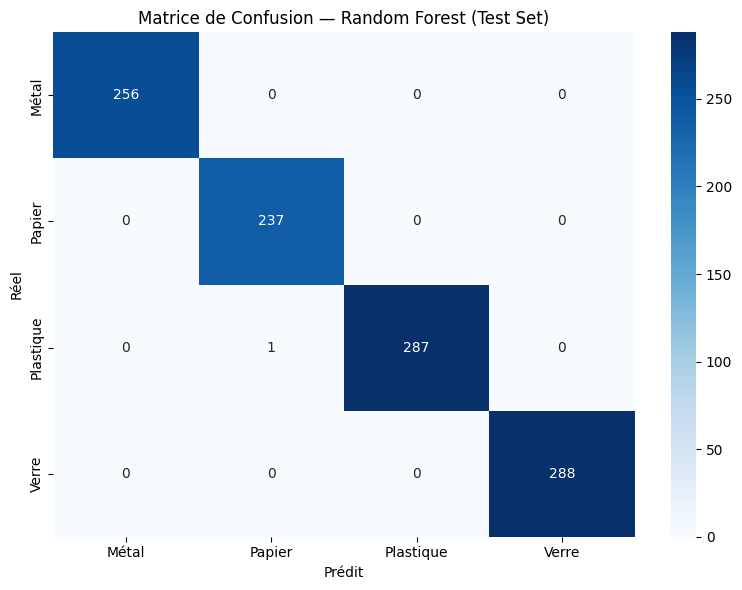

In [10]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=meilleur_modele.classes_,
            yticklabels=meilleur_modele.classes_)
plt.title(f'Matrice de Confusion — {meilleur_nom} (Test Set)')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.tight_layout()
plt.show()

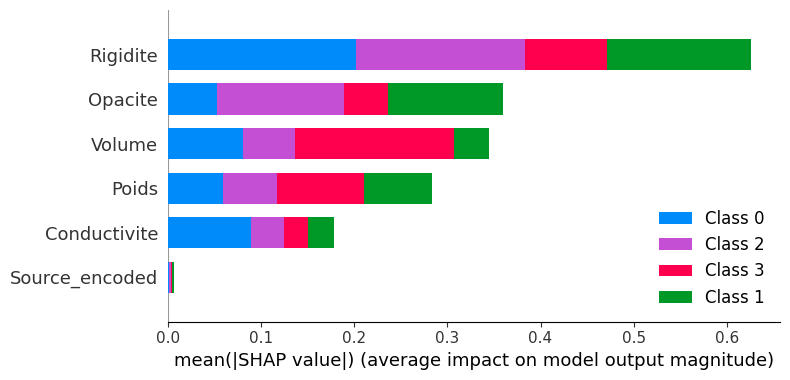


→ Les features les plus importantes sont affichées ci-dessus.
→ Utiliser ces résultats pour la sélection de features dans le pipeline multimodal.


In [11]:
import shap

explainer = shap.TreeExplainer(meilleur_modele)
shap_values = explainer.shap_values(X_test)

# Gestion multiclasse : shap_values est une liste (une array par classe)
if isinstance(shap_values, list):
    shap_mean = np.mean([np.abs(sv) for sv in shap_values], axis=0)
else:
    shap_mean = np.abs(shap_values)

shap.summary_plot(shap_mean, X_test, feature_names=features, plot_type='bar')
print("\n→ Les features les plus importantes sont affichées ci-dessus.")
print("→ Utiliser ces résultats pour la sélection de features dans le pipeline multimodal.")

In [12]:
# Vérifier overfitting
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

acc_train = accuracy_score(y_train, rf.predict(X_train))
acc_val = accuracy_score(y_val, rf.predict(X_val))
acc_test = accuracy_score(y_test, rf.predict(X_test))

print(f"Accuracy TRAIN : {acc_train:.4f}")
print(f"Accuracy VAL   : {acc_val:.4f}")
print(f"Accuracy TEST  : {acc_test:.4f}")

if acc_train == 1.0 and acc_test == 1.0:
    print("\n Pas d'overfitting - dataset naturellement bien séparé")
elif acc_train == 1.0 and acc_test < 0.90:
    print("\n OVERFITTING détecté !")

Accuracy TRAIN : 1.0000
Accuracy VAL   : 1.0000
Accuracy TEST  : 0.9991


In [13]:
# Vérifier si une feature révèle directement la cible
print("=== CORRELATION FEATURES / CIBLE ===")
for col in features:
    correlation = df_ml[col].corr(df_ml['Categorie_encoded'])
    print(f"{col:20s} → corrélation avec Categorie : {correlation:.4f}")

=== CORRELATION FEATURES / CIBLE ===
Poids                → corrélation avec Categorie : 0.5741
Volume               → corrélation avec Categorie : 0.6225
Conductivite         → corrélation avec Categorie : -0.7313
Opacite              → corrélation avec Categorie : -0.0365
Rigidite             → corrélation avec Categorie : 0.1451
Source_encoded       → corrélation avec Categorie : 0.0142


In [14]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

# Préparer données
X_reg = df_ml[features]
y_reg = df_ml['Prix_Revente']

X_train_r, X_temp_r, y_train_r, y_temp_r = train_test_split(
    X_reg, y_reg, test_size=0.30, random_state=42
)
X_val_r, X_test_r, y_val_r, y_test_r = train_test_split(
    X_temp_r, y_temp_r, test_size=0.50, random_state=42
)

print(f"Train : {len(X_train_r)} | Val : {len(X_val_r)} | Test : {len(X_test_r)}")
# Plusieurs modèles
modeles_reg = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'SVR': SVR()
}

resultats_reg = {}
for nom, modele in modeles_reg.items():
    modele.fit(X_train_r, y_train_r)
    y_pred = modele.predict(X_test_r)
    rmse = np.sqrt(mean_squared_error(y_test_r, y_pred))
    r2 = r2_score(y_test_r, y_pred)
    resultats_reg[nom] = {'RMSE': rmse, 'R2': r2}
    print(f"{nom:25s} → RMSE: {rmse:.4f} | R²: {r2:.4f}")

Train : 4986 | Val : 1068 | Test : 1069
Linear Regression         → RMSE: 3.5584 | R²: 0.7116
Ridge                     → RMSE: 3.5583 | R²: 0.7116
Random Forest             → RMSE: 0.6416 | R²: 0.9906
Gradient Boosting         → RMSE: 0.8768 | R²: 0.9825
SVR                       → RMSE: 2.6600 | R²: 0.8388


                     RMSE      R2
Random Forest      0.6416  0.9906
Gradient Boosting  0.8768  0.9825
SVR                2.6600  0.8388
Ridge              3.5583  0.7116
Linear Regression  3.5584  0.7116


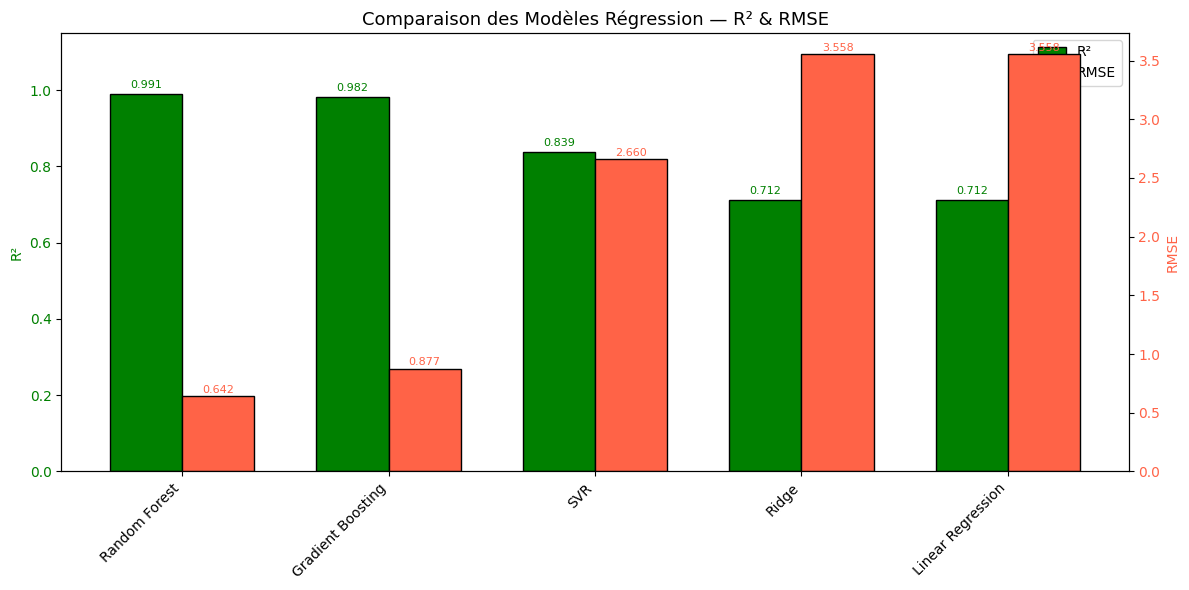

In [20]:
df_reg = pd.DataFrame(resultats_reg).T.sort_values('R2', ascending=False)
print(df_reg.round(4))

fig, ax1 = plt.subplots(figsize=(12, 6))

x = range(len(df_reg))
width = 0.35

# R² sur axe gauche
bars1 = ax1.bar([i - width/2 for i in x], df_reg['R2'], width,
                label='R²', color='green', edgecolor='black')
ax1.set_ylabel('R²', color='green')
ax1.tick_params(axis='y', labelcolor='green')
ax1.set_ylim(0, 1.15)

# RMSE sur axe droit
ax2 = ax1.twinx()
bars2 = ax2.bar([i + width/2 for i in x], df_reg['RMSE'], width,
                label='RMSE', color='tomato', edgecolor='black')
ax2.set_ylabel('RMSE', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')

# Valeurs au dessus des barres
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, color='green')
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, color='tomato')

ax1.set_title('Comparaison des Modèles Régression — R² & RMSE', fontsize=13)
ax1.set_xticks(list(x))
ax1.set_xticklabels(df_reg.index, rotation=45, ha='right')

# Légende combinée
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

In [21]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

# Sélection automatique du meilleur régresseur selon R²
meilleur_reg_nom = pd.DataFrame(resultats_reg).T['R2'].idxmax()
meilleur_reg = modeles_reg[meilleur_reg_nom]

# Sauvegarde
joblib.dump(meilleur_modele, '../models/classifier_best.pkl')
joblib.dump(meilleur_reg,    '../models/regressor_best.pkl')

print(" Modèles sauvegardés !")
print(f"   → models/classifier_best.pkl  ({meilleur_nom})")
print(f"   → models/regressor_best.pkl   ({meilleur_reg_nom})")

 Modèles sauvegardés !
   → models/classifier_best.pkl  (Random Forest)
   → models/regressor_best.pkl   (Random Forest)
